### Célula 1: Configuração do Ambiente e Arquitetura Modular
Importação das bibliotecas base e carregamento dos nossos módulos internos (`core` e `utils`). A modularização mantém o notebook focado apenas na orquestração e análise visual da estratégia.

In [73]:
# Core libraries
import importlib
import numpy as np
from itertools import combinations

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Variables
import config as cfg
importlib.reload(cfg)

import core.analyse as an
importlib.reload(an)

import core.dataset as dt
importlib.reload(dt)

import core.models as model
importlib.reload(model)

import core.backtest as backT
importlib.reload(backT)

import utils.metrics as metric
importlib.reload(metric)

import utils.io as io
importlib.reload(io)

<module 'utils.io' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\financial-market-analysis\\src\\utils\\io.py'>

### Célula 2: Extração de Dados de Mercado
Recolha das cotações históricas diárias (via `yfinance` ou API equivalente) para o universo de ativos (*Tickers*) previamente definido no ficheiro de configuração.

In [74]:
if cfg.DOWNLOAD_STOCKS is True:
    prices = io.get_stock_data(cfg.TICKERS)
    print("All data downloaded.")

[*********************100%***********************]  501 of 501 completed


-> Dados descarregados: 2596 dias, 501 ações.
-> Ações recentes/com falhas removidas: 34
-> DADOS FINAIS PARA O BOT: 2452 dias, 467 ações.
All data downloaded.


### Célula 3: Divisão Temporal (Look-Ahead Bias Prevention)
Separação estrita dos dados em dois períodos: Formação (2016-2023) para treino dos modelos e descoberta de relações estatísticas, e Trading/Testing (2024-2026) para simulação num ambiente cego (*Out-of-Sample*).

In [75]:
prices = prices.dropna()

# Prevenir Look-Ahead Bias
# Usamos 2016-2023 para encontrar a estrutura dos pares (Formation)
# Usamos 2024-2026 para os Agentes operarem (Trading/Testing)

prices_formation = prices.loc[:cfg.SPLIT_DATE]
prices_trading = prices.loc[cfg.SPLIT_DATE:]

print(f"Período de Formação (PCA/Cointegração): {prices_formation.shape[0]} dias")
print(f"Período de Trading (Agentes MAS): {prices_trading.shape[0]} dias")

Período de Formação (PCA/Cointegração): 1926 dias
Período de Trading (Agentes MAS): 527 dias


### Célula 4: Cálculo de Retornos (Período de Formação)
Cálculo dos retornos percentuais diários aplicados exclusivamente aos dados de formação, garantindo que o motor de descoberta não tem acesso a volatilidade futura.

In [76]:
# Calculamos os retornos APENAS nos dados de Formação
returns_formation = prices_formation.pct_change().dropna()
returns_formation.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2016-07-06,0.016457,0.005685,0.023417,0.035244,-0.002116,0.003714,0.004750,0.001806,0.004053,0.001179,...,0.014141,0.009315,0.001325,0.011503,0.016503,0.006711,0.013608,0.015256,-0.014283,0.012421
2016-07-07,-0.001124,0.004292,0.000947,0.012981,-0.002261,-0.007224,-0.000420,0.008836,0.000000,0.000856,...,0.000664,-0.010786,-0.022281,-0.012010,0.001096,0.008889,0.001663,0.001971,0.001279,-0.008318
2016-07-08,0.023863,0.007713,0.011509,0.012814,0.002550,0.021384,0.017343,0.031993,0.032288,0.010375,...,0.017585,0.008880,0.006092,0.006239,0.017094,0.024229,0.017198,0.023521,0.018940,0.016985
2016-07-11,-0.001759,0.003103,0.002962,0.005491,-0.000283,0.003041,0.003616,0.008832,-0.007360,0.007092,...,0.018585,0.048468,-0.004037,0.003742,0.012498,-0.006452,0.007929,0.001521,0.007310,-0.004330
2016-07-12,0.024890,0.004537,0.017871,0.008310,-0.003958,0.009008,0.004118,0.012704,0.003012,-0.003469,...,0.019526,0.025505,-0.020491,0.011290,0.002766,0.017316,-0.002430,0.003038,0.030272,0.012011


### Célula 5: Descoberta de Pares (RMT e HDBSCAN)
Filtragem matemática do ruído do mercado usando a Teoria das Matrizes Aleatórias (RMT) de Marchenko-Pastur, seguida da aplicação do algoritmo HDBSCAN para encontrar *clusters* de ações estruturalmente correlacionadas.

Total de ações (N): 467 | Total de dias (T): 1925
Limite de Ruído Marchenko-Pastur (lambda_max): 2.2277
-> Componentes Principais Retidos (Sinal Puro): 17


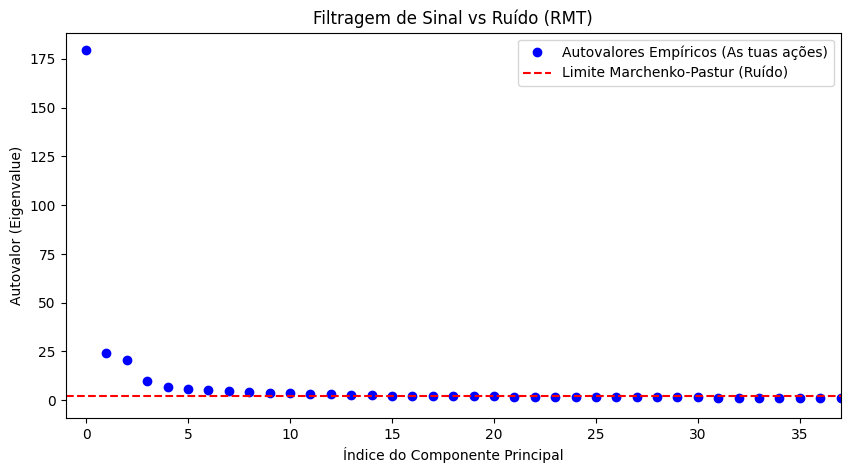

Resumo do HDBSCAN:
-> 116 clusters estruturais encontrados.
-> 117 ações rejeitadas como ruído.



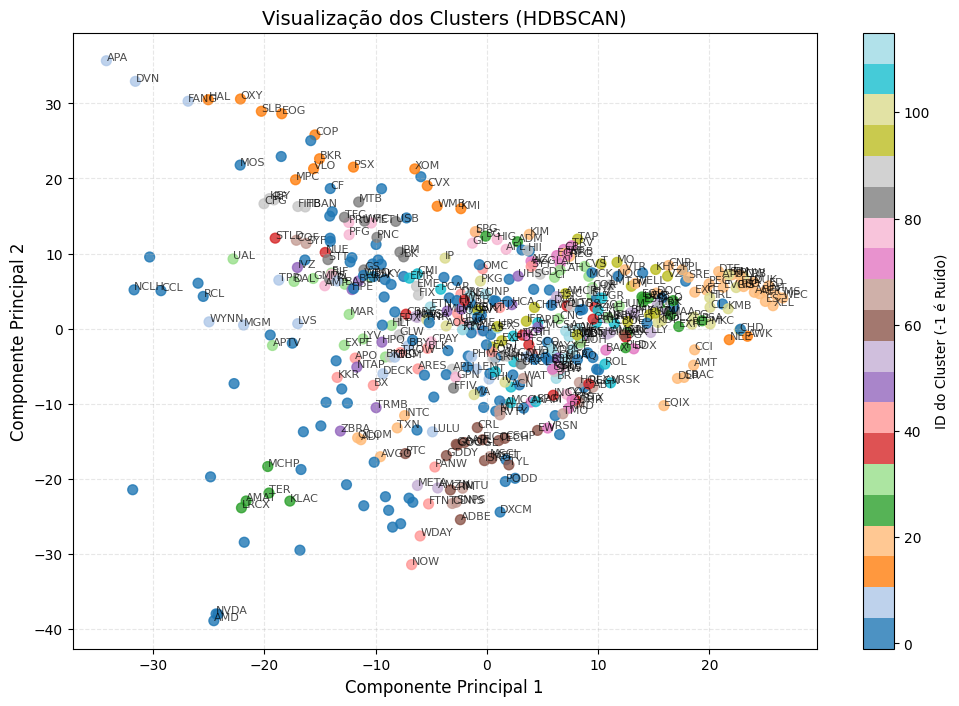


Pares Candidatos Extraídos: 660


In [77]:
# 1. Filtro de Ruído Institucional (Marchenko-Pastur)
X_pca_sota = an.calculate_RMT(returns_formation)

# 2. Aplicar o HDBSCAN (Ajusta-se automaticamente às densidades)
pairs_grouped, clusters_dict = an.RMT_clustering_hdbscan(X_pca_sota, returns_formation)

# 3. Extrair todas as combinações (2 a 2) dentro dos clusters encontrados
candidate_pairs = []
for cluster_list in clusters_dict.values():
    if len(cluster_list) > 1:
        for combo in combinations(cluster_list, 2):
            candidate_pairs.append(list(combo))

print(f"\nPares Candidatos Extraídos: {len(candidate_pairs)}")

### Célula 6: Validação Estrutural (Cointegração e Elasticidade)
Filtra as combinações candidatas garantindo estacionariedade forte (Teste ADF) e velocidade de reversão rápida (Expoente de Hurst < 0.4). O *Hedge Ratio* (Beta) de cada par é calculado recorrendo ao método simétrico de *Total Least Squares* (TLS).

In [78]:
print(f"A testar {len(candidate_pairs)} pares candidatos (TLS + ADF + Hurst)...")
valid_pairs_df, spreads_dict = an.validate_pairs(candidate_pairs, prices_formation, prices)

print(f"-> Sobreviveram {len(valid_pairs_df)} pares institucionais!")
display(valid_pairs_df.head(10))

A testar 660 pares candidatos (TLS + ADF + Hurst)...
-> Sobreviveram 21 pares institucionais!


,ativo_y,ativo_x,beta_tls,adf_p_value,hurst
9,ATO,SRE,0.916501,0.023247,0.314639
12,ED,NI,1.190955,0.014008,0.339181
0,GOOG,GOOGL,1.024177,0.002857,0.342913
15,WEC,XEL,1.012136,0.006818,0.354946
7,AEP,SRE,0.965123,0.011782,0.355722
20,MLM,VMC,1.303872,0.000440,0.362826
13,ED,SRE,0.758969,0.021942,0.369120
1,MCO,SPGI,0.989879,0.000076,0.372634
11,DTE,SRE,0.970511,0.049475,0.375719
4,AEE,WEC,0.980382,0.044226,0.384421


### Célula 7: Feature Engineering e Tripla Barreira
Modelação da física diária do *spread*. Calcula métricas como a ECDF (anomalias de preço) e os parâmetros de *Ornstein-Uhlenbeck* (velocidade, centro de gravidade e meia-vida). Por fim, aplica o Método da Tripla Barreira para rotular os sinais históricos como Sucesso (1) ou Fracasso (0) para treino supervisionado.

In [79]:
print(f"A processar pares institucionais. Isto pode demorar...")
global_meta_dataset = dt.build_global_dataset(
    valid_pairs_df, spreads_dict, cfg.SPLIT_DATE, 
    cfg.WINDOW, cfg.LOWER_PERCENTILE, cfg.UPPER_PERCENTILE, cfg.SL_MULTIPLIER
)

print(f"\n--- DATASET GLOBAL CONSTRUÍDO ---")
print(f"Total Trades Históricos: {len(global_meta_dataset)}")
print(f"Win-Rate Agente Base: {(global_meta_dataset['target'].mean() * 100):.2f}%")

A processar pares institucionais. Isto pode demorar...


100%|██████████| 21/21 [01:11<00:00,  3.41s/it]


--- DATASET GLOBAL CONSTRUÍDO ---
Total Trades Históricos: 908
Win-Rate Agente Base: 14.65%


### Célula 8: O Meta-Agente (Treino SOTA)
Treino do modelo preditivo de *Machine Learning* (Ensemble). Utiliza *TimeSeriesSplit* com *Embargo* (Purged K-Fold) para prevenir o vazamento de informação temporal (*Data Leakage*), extraindo a importância que o modelo dá a cada variável.

In [80]:
meta_agent, cv_scores, importances = model.train_meta_agent(global_meta_dataset)

print("=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===")
print(f"Accuracy Preditiva: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")
print("\n-> Importância das Variáveis:")
print(importances)

# Atribuir previsões ao dataset
global_meta_dataset['Prob_Sucesso'] = meta_agent.predict_proba(
    global_meta_dataset[['ecdf', 'theta', 'half_life', 'volatility', 'side']]
)[:, 1]

=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===
Accuracy Preditiva: 0.67 (+/- 0.06)

-> Importância das Variáveis:
half_life     0.385910
theta         0.358582
volatility    0.217449
ecdf          0.023890
side          0.014168
dtype: float64


### Célula 9: Análise de Risco (Threshold Tuning)
Ajuste interativo do limiar de exigência probabilística do Meta-Agente. Permite ao analista quantitativo decidir o ponto ótimo de equilíbrio entre o número de trades gerados (*Recall*) e a fiabilidade estatística (*Precision*).

In [81]:
# 1. Gerar a tabela de análise de Limiares
probs_sucesso = global_meta_dataset['Prob_Sucesso']
y_real = global_meta_dataset['target']

print("=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 ===")
df_thresholds = metric.tune_threshold(probs_sucesso, y_real, thresholds=np.arange(0.5, 0.9, 0.05))
display(df_thresholds)

# Gravar a autorização no dataset
global_meta_dataset['Trade_Autorizado'] = (global_meta_dataset['Prob_Sucesso'] >= cfg.LIMIAR_FINAL).astype(int)

print(f"\n-> Usando o Limiar de {cfg.LIMIAR_FINAL*100}%, o bot autorizou {global_meta_dataset['Trade_Autorizado'].sum()} trades durante o período de formação.")

=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 ===


,Limiar (%),Trades Aprovados,Precision (Win-Rate),Recall (Oportunidades)
0,50%,327,28.4%,69.9%
1,55%,248,33.1%,61.7%
2,60%,182,39.0%,53.4%
3,65%,114,49.1%,42.1%
4,70%,60,51.7%,23.3%
5,75%,15,60.0%,6.8%
6,80%,0,0.0%,0.0%
7,85%,0,0.0%,0.0%



-> Usando o Limiar de 65.0%, o bot autorizou 114 trades durante o período de formação.


### Célula 10: Motor de Backtest Institucional (Out-of-Sample)
Simulação *Walk-Forward* no período 2024-2026. O motor avalia os sinais do Agente Base, requer autorização ao Meta-Agente, calcula a exposição usando o Critério de Kelly com alavancagem de 3x, e fecha posições dinamicamente através da Tripla Barreira.

In [82]:
print("=== INICIAR BACKTEST OUT-OF-SAMPLE (2024 - 2026) ===")

# Lançar o motor
trades_df = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, 
    spreads_dict=spreads_dict, 
    meta_agent=meta_agent, 
    split_date=cfg.SPLIT_DATE,
    window=cfg.WINDOW, 
    lower_pct=cfg.LOWER_PERCENTILE, 
    upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, 
    limiar_final=cfg.LIMIAR_FINAL, 
    alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

print(f"\n--- BACKTEST CONCLUÍDO ---")
if not trades_df.empty:
    print(f"Total de trades executados na fase cega: {len(trades_df)}")
    display(trades_df.head())
else:
    print("O Meta-Agente não executou operações.")

=== INICIAR BACKTEST OUT-OF-SAMPLE (2024 - 2026) ===


OOS Backtest: 100%|██████████| 21/21 [01:35<00:00,  4.55s/it]


--- BACKTEST CONCLUÍDO ---
Total de trades executados na fase cega: 94


,pair,entry_date,exit_date,side,prob_ml,kelly_fraction,duration,exit_reason,pnl_spread_pts
0,ATO_SRE,2024-08-05,2024-08-22,-1,0.677072,0.2,17,Time-Stop,0.010756
1,ATO_SRE,2025-05-27,2025-06-11,1,0.753438,0.2,15,Time-Stop,0.008654
2,ATO_SRE,2025-07-23,2025-08-07,1,0.694533,0.2,15,Time-Stop,-0.001120
3,ED_NI,2024-06-24,2024-07-10,1,0.687222,0.2,16,Time-Stop,-0.028989
4,ED_NI,2024-08-23,2024-09-09,1,0.749503,0.2,17,Time-Stop,0.010500


### Célula 11: Relatório de Performance (Quant Tearsheet)
Avaliação final da rentabilidade e risco da estratégia. Compila o registo de operações num relatório detalhado (Win-Rate, Risco/Recompensa, taxas de paragem) e gera visualizações da Curva de Capital (*Equity Curve*) e respetivo *Drawdown* máximo histórico.

=== PERFORMANCE OUT-OF-SAMPLE (2024-2026) ===
-> Total Trades: 94
-> Win-Rate: 17.02% (Trades que bateram no mu)
-> Stop-Loss Rate: 12.77%
-> Time-Stop Rate: 70.21%
-> Lucro Médio p/ Trade Vencedor: 0.54% do capital
-> Perda Média p/ Trade Perdedor: -0.51% do capital
-> Risco/Recompensa Realizado: 1.06
-> Retorno Total da Estratégia: 6.66%
-> Max Drawdown (A maior dor financeira): -6.07%


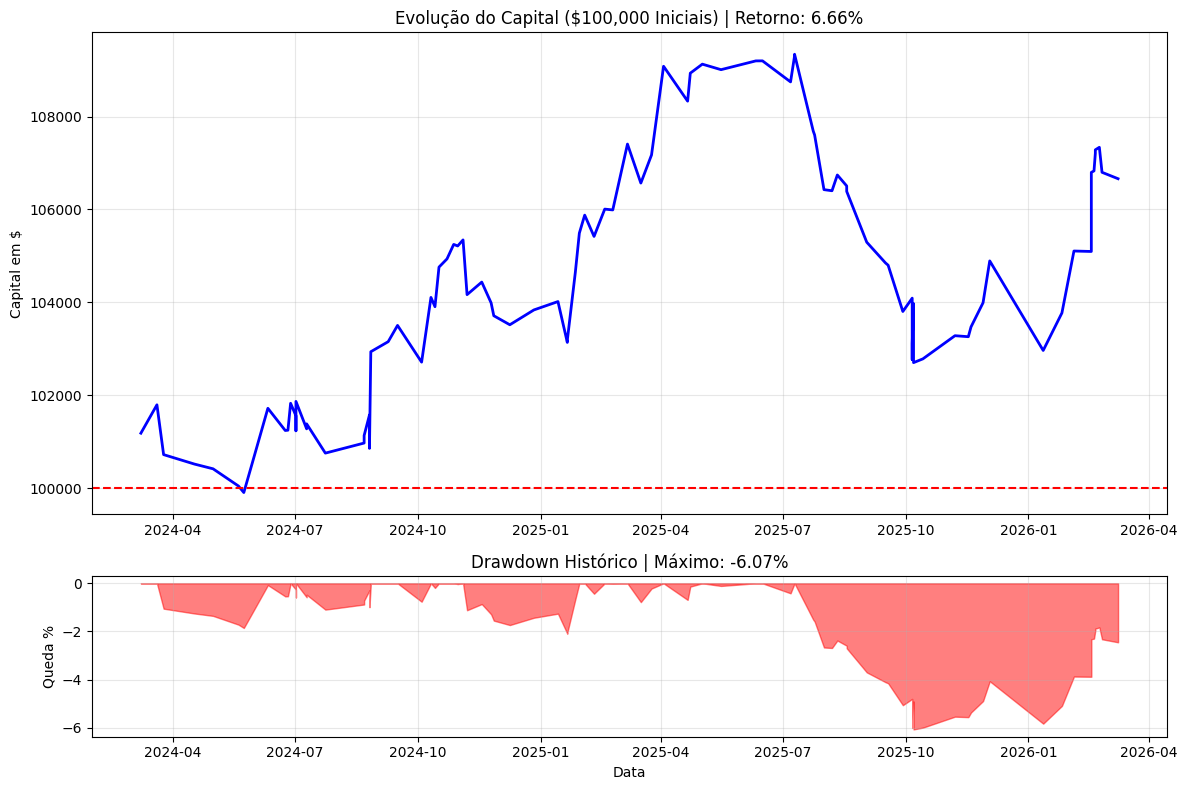

In [83]:
# Gerar o relatório visual e estatístico (Assume que CAPITAL_INICIAL foi definido na Célula 11)
io.generate_tearsheet(trades_df, capital_inicial=cfg.CAPITAL_INICIAL)